# Get the codes of interest to work with:
* BB Codes
* RSC 

In [5]:
# RSC, just use stim to get same distances as BB codes 

import stim
from ldpc_post_selection.decoder import SoftOutputsBpLsdDecoder

def get_rsc_circuits(p,d_list,basis, rds=None):
    """
    Use STIM to get rotated surface code circuits with circuit-level errors

    :param d_list: the list of rsc d's to run 
    :param basis: the memory experiment basis
    :param p: the probability of physical error on a qubit. Same p used for spam, idle, gate errors.

    :return: the list of circuits generated by STIM with these inputs
    """
    circuits = []
    code_info = []
    for d in d_list:
        if not rds:
            rds = d
        circuit = stim.Circuit.generated(f"surface_code:rotated_memory_{basis}",rounds=rds, distance=d,
                                    after_clifford_depolarization=p,
                                    before_round_data_depolarization=p,
                                    before_measure_flip_probability=p,
                                    after_reset_flip_probability=p,
                                    )
        circuits += [circuit]
        code_info += [get_parity_and_logs_rsc(d,basis)]
    return circuits, code_info

def get_parity_and_logs_rsc(d, basis):
    """
    Use stim circuit to get the parity check matrix 
    """
    circuit = stim.Circuit.generated(
    f"surface_code:rotated_memory_{basis}",
    rounds=1,
    distance=d,
    after_clifford_depolarization=0,
    before_measure_flip_probability=0,
    after_reset_flip_probability=0,
    # Use data depolarization to define the H matrix columns (the qubits)
    before_round_data_depolarization=0.001 
    )

    # 2. Use the package's decoder to extract the matrices
    # The decoder internally converts the DEM to check/logical matrices
    bplsd = SoftOutputsBpLsdDecoder(
        circuit=circuit,
        detector_time_coords=0 # Only one round, so time coord isn't strictly needed here
    )

    h = bplsd.H # This is your code-level H matrix
    l = bplsd.obs_matrix   # This is your logical operator matrix
    return h, l


In [6]:
# BB code

# I am going through [[72,12,6]], [[90,8,10]], [[144,12,12]] 

from quits.qldpc_code import BbCode, BpcCode, HgpCode
from quits.decoder import sliding_window_bposd_circuit_mem,detector_error_model_to_matrix
from quits.simulation import get_stim_mem_result
from quits import ErrorModel
import numpy as np



def get_BB_circuits(bb_code_param_dict, basis, p):
    """
    Use QUITS to get BB code circuits with circuit-level errors

    :param bb_code_param_dict: the dictionary mapping [[n,k,d]] tuple for BB codes to their l,m,A powers, B powers. 
    :param basis: the memory experiment basis
    :param p: the probability of physical error on a qubit. Same p used for spam, idle, gate errors.

    :return: the list of circuits generated by QUITS with these inputs
    """


    circuits = []
    codes = []

    error_model = ErrorModel(
    idle_error=p,
    sqgate_error=p,
    tqgate_error=p,
    spam_error=p,
    )

    for (n,k,d) in bb_code_param_dict:
        code_params = bb_code_param_dict[(n,k,d)]

        bb = BbCode(
        l=code_params['l'],
        m=code_params['m'],
        A_x_pows=code_params['A_x_pows'],
        A_y_pows=code_params['A_y_pows'],
        B_x_pows=code_params['B_x_pows'],
        B_y_pows=code_params['B_y_pows'],
        )

        custom_circuit = bb.build_circuit(strategy="custom", num_rounds=d, basis=basis, error_model=error_model) # num_rounds fixed to d for us
        labeled_circuit = fix_bb_circuit_for_sliding_window(custom_circuit, d)
        circuits.append(labeled_circuit)
        codes.append(bb)

    return circuits, codes

def get_BB_circuit(d, basis, p):
    d_dict = {6:{'l':6, 'm':6, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [1,2], 'B_y_pows':[3]},
              10: {'l':15, 'm':3, 'A_x_pows': [9], 'A_y_pows': [1,2], 'B_x_pows': [2,7], 'B_y_pows':[0]},
              12:{'l':12, 'm':6, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [1,2], 'B_y_pows':[3]},}
    code_params = d_dict[d]

    error_model = ErrorModel(
        idle_error=p,
        sqgate_error=p,
        tqgate_error=p,
        spam_error=p,
        )

    bb = BbCode(
        l=code_params['l'],
        m=code_params['m'],
        A_x_pows=code_params['A_x_pows'],
        A_y_pows=code_params['A_y_pows'],
        B_x_pows=code_params['B_x_pows'],
        B_y_pows=code_params['B_y_pows'],
    )

    custom_circuit = bb.build_circuit(strategy="custom", num_rounds=d, basis=basis, error_model=error_model) # num_rounds fixed to d for us
    labeled_circuit = fix_bb_circuit_for_sliding_window(custom_circuit, d)
    return labeled_circuit, bb

def fix_bb_circuit_for_sliding_window(original_circuit, num_rounds):
    """
    Flattens a BB circuit and injects (t,) coordinates for sliding window decoding.
    """
    # 1. Flatten to ensure each round's detectors can have unique time coordinates
    flattened = original_circuit.flattened()
    detectors_per_round = original_circuit.num_detectors//(num_rounds+2) # num_rounds should be d
    new_circuit = stim.Circuit()
    detector_count = 0

    for instr in flattened:
        if instr.name == "DETECTOR":
            time_step = detector_count // detectors_per_round
            
            # Append detector with the new coordinate [time_step]
            new_circuit.append(
                "DETECTOR", 
                instr.targets_copy(), 
                [time_step] # This becomes index 0 for the decoder
            )
            detector_count += 1
        else:
            new_circuit.append(instr)
            
    return new_circuit

In [4]:
# set (n,k,d) tuple to get the params I need
# BB - [[72,12,6]], [[90,8,10]], [[144,12,12]] 
# not sure what these mean, will need to understand before writeup
bb_code_param_dict = {
                    (72,12,6):{'l':6, 'm':6, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [1,2], 'B_y_pows':[3]},
                    (90,8,10):{'l':15, 'm':3, 'A_x_pows': [9], 'A_y_pows': [1,2], 'B_x_pows': [2,7], 'B_y_pows':[0]},
                    (144,12,12):{'l':12, 'm':6, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [1,2], 'B_y_pows':[3]},
                    }

d_list = [6,10,12] # maybe change to odd numbers later since don't use even # rsc for some reason
p = 0.005
basis = 'x'

bb_circuits, bb_codes = get_BB_circuits(bb_code_param_dict=bb_code_param_dict, basis=basis, p=p)
rsc_circuits, rsc_codes = get_rsc_circuits(p=p, d_list=d_list, basis=basis)

print(repr(bb_circuits[1]))

stim.Circuit('''
    RX 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134
    Z_ERROR(0.005) 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134
    R 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44
    X_ERROR(0.005) 135 136 137 138 1

In [5]:
from realtime_decoding.complementary_gap import get_boundary_detectors

circuits = get_rsc_circuits(0.0, [3], 'z')

left_detectors = get_boundary_detectors(circuits[0], side="top")
print(f"left boundary ids {left_detectors}")
circuits[0].diagram("timeline-svg")

AttributeError: 'list' object has no attribute 'get_detector_coordinates'

# Get the complementary and cluster gaps

In [6]:
# get comp gaps for mwpm 
from pymatching import Matching
from realtime_decoding.complementary_gap import get_detector_inds_for_sc, get_complementary_gap

# wait for eva to get back and generalize this ... for now just do path of least resistance and use hers + X memory only
# maybe use detector coords methods - see the post selection notebook

def get_comp_gap(circuit, det_events, obs, d, basis):
    comp_gap, signed_gap, cond_p_L = get_complementary_gap(circuit, det_events, obs, basis)
    return comp_gap, signed_gap, cond_p_L

In [3]:
# get cluster gap - uses https://arxiv.org/pdf/2510.05795
from realtime_decoding.cluster_based_soft_outputs import get_cluster_soft_output_from_bplsd_glocal_decoding

# get cluster gaps for circuits 
def get_cluster_gap(circuit, det_events, obs, cluster_method = 'cluster_llrs', order=2, decoder=None):
   return get_cluster_soft_output_from_bplsd_glocal_decoding(circuit, cluster_method, order, det_events, obs, decoder=decoder)

### test the gaps

In [ ]:
# comp gap histogram tests 
import matplotlib.pyplot as plt


# probably a boundaries issue just not sure what it is

d_list = [5,7,9]
colors = ['blue','orange','green']
alphas = [0.5,0.4,0.3]
mem_type = "z"
p = 0.01
shots=10**4

circuits = get_rsc_circuits(p, d_list, mem_type)

for i,d in enumerate(d_list):
    circuit = circuits[i]
    sampler = circuit.compile_detector_sampler()
    det_events, obs_flips = sampler.sample(shots=shots, separate_observables=True)
    gap, signed_gap, cond_pL = get_comp_gap(circuit, det_events, obs_flips, d, mem_type)
    plt.hist(signed_gap, bins=200, color=colors[i], label=f"d={d}", alpha=alphas[i])
    plt.xlabel('Complementary gap [dB]')
    plt.ylabel('Unormalized cnts')
    plt.legend()
plt.yscale('log')

In [ ]:
# comp gap pL



In [13]:
# Defining the soft-output BP+LSD decoder
from ldpc_post_selection.decoder import SoftOutputsBpLsdDecoder

circuit = bb_circuits[0]

bplsd = SoftOutputsBpLsdDecoder(
    circuit=circuit,
    max_iter=30,
    bp_method="minimum_sum",
    lsd_method="LSD_0",
    lsd_order=0,
    ms_scaling_factor=1.0,
)

circuit = bb_circuits[0]
# Create a single sample
sampler = circuit.compile_detector_sampler()
det, obs = sampler.sample(shots=1, separate_observables=True)

# Decode the sample and obtain soft outputs
correction, correction_bp, converge, soft_outputs = bplsd.decode(det[0])
obs_correction = correction @ bplsd.obs_matrix.T % 2
success = np.all(obs[0] == obs_correction)

from pprint import pprint

print("Correction:", correction)
print("Correction from BP (valid only when BP converges):", correction_bp)
print("Whether BP converges:", converge)
print("Decoding success:",success)
print()
print("Soft outputs:")
pprint(soft_outputs)

Correction: [False False False ... False False False]
Correction from BP (valid only when BP converges): [False False False ... False False False]
Whether BP converges: False
Decoding success: True

Soft outputs:
{'cluster_llrs': array([1.32096937e+04, 3.67282411e+00, 5.00797758e+00, 3.57206294e+00,
       5.92425580e+00, 3.67282411e+00, 5.92425580e+00, 3.67282411e+00,
       5.92425580e+00, 5.92425580e+00, 3.67282411e+00, 1.72339881e+02,
       3.57206294e+00, 4.17469540e+00]),
 'cluster_sizes': array([2542,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
         38,    1,    1]),
 'clusters': array([0, 0, 0, ..., 0, 0, 0], shape=(2592,)),
 'detector_density': np.float64(0.2048611111111111),
 'initial_logical_class': array([False, False, False, False, False,  True,  True, False,  True,
       False,  True,  True]),
 'pred_llr': 107.27852292856834}


In [15]:
from tqdm import tqdm
from ldpc_post_selection.cluster_tools import compute_cluster_norm_fraction

shots = 1000
circuit = bb_circuits[0]
sampler = circuit.compile_detector_sampler(seed=42)
det, obs = sampler.sample(shots=shots, separate_observables=True)

fails = []
norm_fracs = []

for i_sample in tqdm(list(range(shots))):
    correction, _, _, soft_outputs = bplsd.decode(det[i_sample])
    obs_correction = correction @ bplsd.obs_matrix.T % 2
    fail = np.any(obs[i_sample] != obs_correction)
    norm_frac = compute_cluster_norm_fraction(soft_outputs["cluster_sizes"], 2)
    fails.append(fail)
    norm_fracs.append(norm_frac)
print(np.any(fails))
print(norm_fracs)

errors, norm_fracs_fn, cluster_pL = get_cluster_gap(circuit, det, obs, cluster_method='cluster_sizes')
print(np.any(errors))
print(norm_fracs_fn)

100%|██████████| 1000/1000 [00:08<00:00, 112.85it/s]


True
[0.001590704330871011, 0.02242637597119386, 0.03512921623351306, 0.002004688434686201, 0.02858325068208558, 0.14544957754724647, 0.023571867855540322, 0.07716242281539412, 0.020879720876133965, 0.002077609879295719, 0.059035342047402954, 0.012077527656248865, 0.008238486305579716, 0.035122860113398276, 0.027055730543652373, 0.002963404995319679, 0.12962962962962962, 0.05209333465931558, 0.07562023646289302, 0.00214805723874615, 0.0018502436432533639, 0.002644928472376946, 0.002182428336995517, 0.05557028911283011, 0.10339506172839506, 0.03320367659208577, 0.009006649328648728, 0.011287607128339346, 0.0019672143185157347, 0.004803202005396887, 0.0018900383817771435, 0.06057221631214345, 0.050941998492501236, 0.023193114761094348, 0.04900906333273178, 0.0019672143185157347, 0.0019672143185157347, 0.0024093356475302463, 0.009014908522799323, 0.0018095739814133602, 0.037057125467779686, 0.019732580019358674, 0.0016368212527466377, 0.0022495956384434032, 0.05364874307347579, 0.03437541

100%|██████████| 1000/1000 [00:08<00:00, 112.62it/s]

custom counts Counter({'C0.0019': 0.05100000000000004, 'C0.002': 0.046000000000000034, 'C0.0021': 0.037000000000000026, 'C0.0018': 0.035000000000000024, 'C0.0017': 0.03200000000000002, 'C0.0022': 0.02900000000000002, 'C0.0016': 0.02100000000000001, 'C0.0024': 0.011000000000000003, 'C0.0014': 0.010000000000000002, 'C0.0023': 0.009000000000000001, 'E0.0286': 0.008, 'E0.0232': 0.006, 'E0.022': 0.006, 'C0.0015': 0.006, 'E0.0417': 0.006, 'E0.0305': 0.006, 'C0.0205': 0.006, 'C0.0026': 0.005, 'E0.0332': 0.005, 'C0.009': 0.005, 'E0.0413': 0.005, 'E0.0625': 0.005, 'E0.0317': 0.005, 'C0.0079': 0.005, 'E0.0752': 0.005, 'E0.002': 0.005, 'E0.0278': 0.005, 'E0.0255': 0.005, 'E0.0297': 0.005, 'C0.0025': 0.005, 'E0.0159': 0.005, 'E0.0224': 0.004, 'C0.0209': 0.004, 'C0.0351': 0.004, 'E0.0556': 0.004, 'E0.0197': 0.004, 'E0.0664': 0.004, 'E0.0147': 0.004, 'E0.0259': 0.004, 'E0.0467': 0.004, 'E0.0421': 0.004, 'E0.0205': 0.004, 'E0.0525': 0.004, 'E0.0178': 0.004, 'C0.0029': 0.004, 'C0.0255': 0.004, 'E0.045

In [ ]:
# cluster gap failure rate stuff to match sim

from ldpc_post_selection.decoder import SoftOutputsBpLsdDecoder
from statsmodels.stats.proportion import proportion_confint
shots = 10000

# circuits = get_BB_circuits()

circuit = rsc_circuits[1]


sampler = circuit.compile_detector_sampler()
det, obs = sampler.sample(shots=shots, separate_observables=True)

log_errors, norm_fracs, cluster_pL = get_cluster_gap(circuit, det,obs, cluster_method='cluster_llrs')
print(log_errors)
print(norm_fracs)

fails_array = np.array(log_errors)
norm_fracs_array = np.array(norm_fracs)
cutoffs = np.logspace(np.log10(min(norm_fracs)), np.log10(max(norm_fracs)), 100)

mask = norm_fracs_array[np.newaxis, :] <= cutoffs[:, np.newaxis]
num_accepted = mask.sum(axis=1)
num_failures = (mask * fails_array[np.newaxis, :]).sum(axis=1)

failure_rates = num_failures / num_accepted

# Calculate 95% cluster_gap intervals using Wilson score interval
cluster_gap_level = 0.95

# Failure rate cluster_gap intervals
failure_rate_lower, failure_rate_upper = proportion_confint(
    num_failures, num_accepted, alpha=1 - cluster_gap_level, method="wilson"
)


In [ ]:
# Plotting failure and abort rates vs cutoffs

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(5, 3))

# Plot failure rate on left y-axis
color1 = "tab:blue"
ax1.set_xlabel("Cutoff")
ax1.set_ylabel("Failure Rate", color=color1)
ax1.plot(cutoffs, failure_rates, color=color1, label="Failure Rate")
ax1.fill_between(
    cutoffs, failure_rate_lower, failure_rate_upper, color=color1, alpha=0.2
)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Add a legend
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1)

ax1.set_xscale("log")
ax1.set_yscale("log")

ax1.set_xlim(1e-3, 1e-1)
ax1.set_ylim(1e-6, 1)

plt.tight_layout()
plt.show()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
100%|██████████| 10000/10000 [32:10<00:00,  5.18it/s] 
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed: 32.2min finished


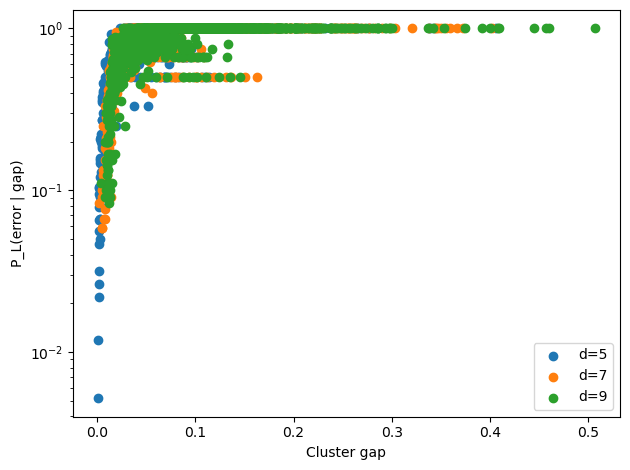

{5: {0.1048: 1.0,
  0.0484: 0.9,
  0.0686: 1.0,
  0.1109: 1.0,
  0.1189: 1.0,
  0.0625: 1.0,
  0.0343: 0.5,
  0.0968: 1.0,
  0.0202: 0.5,
  0.0766: 1.0,
  0.0953: 1.0,
  0.1281: 1.0,
  0.0061: 0.36363636363636365,
  0.0404: 0.875,
  0.0545: 1.0,
  0.0263: 0.8571428571428571,
  0.0122: 0.3571428571428571,
  0.0465: 0.7777777777777778,
  0.1029: 1.0,
  0.1151: 1.0,
  0.0324: 0.75,
  0.109: 1.0,
  0.0606: 1.0,
  0.0808: 1.0,
  0.0747: 1.0,
  0.0183: 0.8333333333333333,
  0.0667: 1.0,
  0.0042: 0.21428571428571427,
  0.0456: 0.6666666666666666,
  0.0835: 0.5,
  0.2034: 1.0,
  0.0526: 1.0,
  0.0385: 1.0,
  0.1409: 1.0,
  0.0103: 0.4666666666666667,
  0.0244: 0.6111111111111112,
  0.0587: 1.0,
  0.0446: 0.875,
  0.0305: 0.7777777777777778,
  0.093: 1.0,
  0.0648: 1.0,
  0.0789: 1.0,
  0.101: 1.0,
  0.1071: 1.0,
  0.0023: 0.1041666666666667,
  0.0164: 0.45454545454545453,
  0.0225: 0.6363636363636365,
  0.0507: 0.8571428571428571,
  0.0366: 0.8333333333333333,
  0.0084: 0.3571428571428571,
  

In [17]:
# cluster gap pL
from joblib import Parallel, delayed
from joblib import Parallel, delayed
import matplotlib.pyplot as plt


def run_gap_conditioned_PL_parallel(circuits,num_shots=10**6,n_jobs=-1,verbose=10):
    #This uses the unsigned gap

    def run_one_distance(d, circuit):
        sampler = circuit.compile_detector_sampler()
        det_events, obs = sampler.sample(num_shots, separate_observables=True)
        _,_,cluster_pL = get_cluster_gap(circuit, det_events, obs, cluster_method='cluster_llrs')
        return d, cluster_pL

    results = Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(run_one_distance)(d, circuits[i]) for i,d in enumerate(d_list)
    )

    # -------- plotting --------
    plt.figure()

    for d, cluster_pL in results:
        # print(d, cluster_pL)
        plt.scatter(
            list(cluster_pL.keys()),
            list(cluster_pL.values()),
            label=f'd={d}'
        )

    plt.xlabel("Cluster gap")
    plt.ylabel("P_L(error | gap)")
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    plt.show()
    

    return dict(results)

num_shots = 10**4
run_gap_conditioned_PL_parallel(bb_circuits,num_shots)


100%|██████████| 10000/10000 [00:10<00:00, 970.01it/s]


custom counts Counter({'C0.0009': 0.11130000000000216, 'C0.0008': 0.11100000000000215, 'C0.0007': 0.09220000000000161, 'C0.001': 0.08990000000000155, 'C0.0006': 0.07200000000000104, 'C0.0011': 0.05960000000000068, 'C0.0005': 0.046100000000000294, 'C0.0012': 0.03910000000000009, 'C0.0004': 0.02259999999999992, 'C0.0013': 0.02099999999999993, 'C0.0003': 0.01409999999999997, 'C0.0': 0.01399999999999997, 'C0.0014': 0.012899999999999977, 'C0.0016': 0.010499999999999992, 'C0.0015': 0.0093, 'C0.0017': 0.008700000000000003, 'C0.0022': 0.008600000000000003, 'C0.002': 0.007400000000000006, 'C0.0019': 0.007000000000000005, 'C0.0021': 0.007000000000000005, 'C0.0018': 0.0067000000000000046, 'C0.0023': 0.006500000000000004, 'C0.0024': 0.006500000000000004, 'C0.0025': 0.005200000000000001, 'C0.003': 0.005, 'C0.0027': 0.0049, 'C0.0038': 0.0048, 'C0.0032': 0.004199999999999998, 'C0.0026': 0.0037999999999999974, 'C0.0031': 0.003499999999999998, 'C0.0034': 0.003499999999999998, 'C0.0028': 0.0033999999999

100%|██████████| 10000/10000 [00:32<00:00, 310.97it/s]


custom counts Counter({'C0.0006': 0.1517999999999996, 'C0.0005': 0.1473000000000001, 'C0.0007': 0.08620000000000144, 'C0.0004': 0.06500000000000083, 'C0.0008': 0.037400000000000044, 'C0.0009': 0.029299999999999878, 'C0.001': 0.021399999999999926, 'C0.0011': 0.018699999999999942, 'C0.0012': 0.01749999999999995, 'C0.0003': 0.01589999999999996, 'C0.0014': 0.013299999999999975, 'C0.0013': 0.012999999999999977, 'C0.0015': 0.011699999999999985, 'C0.0019': 0.011699999999999985, 'C0.0017': 0.01079999999999999, 'C0.0016': 0.010499999999999992, 'C0.002': 0.009499999999999998, 'C0.0018': 0.0091, 'C0.0025': 0.007600000000000007, 'C0.0023': 0.007400000000000006, 'C0.0024': 0.007000000000000005, 'C0.0027': 0.006800000000000005, 'C0.0031': 0.006500000000000004, 'C0.0021': 0.0063000000000000035, 'C0.0022': 0.0063000000000000035, 'C0.0028': 0.006000000000000003, 'C0.0036': 0.005700000000000002, 'C0.0026': 0.005600000000000002, 'C0.0029': 0.005500000000000001, 'C0.0032': 0.005400000000000001, 'C0.0035':

100%|██████████| 10000/10000 [01:06<00:00, 150.03it/s]


custom counts Counter({'C0.0004': 0.15739999999999899, 'C0.0005': 0.10700000000000204, 'C0.0006': 0.047600000000000336, 'C0.0003': 0.044400000000000245, 'C0.0007': 0.03760000000000005, 'C0.0008': 0.03209999999999989, 'C0.001': 0.027699999999999888, 'C0.0009': 0.024699999999999906, 'C0.0011': 0.023599999999999913, 'C0.0013': 0.019599999999999937, 'C0.0012': 0.018599999999999943, 'C0.0014': 0.017099999999999952, 'C0.0015': 0.015599999999999961, 'C0.0016': 0.014599999999999967, 'C0.0019': 0.013399999999999974, 'C0.0018': 0.012899999999999977, 'C0.0017': 0.012699999999999979, 'C0.0023': 0.01089999999999999, 'C0.0025': 0.010399999999999993, 'C0.0022': 0.010399999999999993, 'C0.0024': 0.010299999999999993, 'C0.0026': 0.010299999999999993, 'C0.0028': 0.009799999999999996, 'C0.002': 0.009799999999999996, 'C0.0027': 0.009699999999999997, 'C0.0021': 0.009499999999999998, 'C0.0029': 0.008400000000000005, 'C0.0031': 0.008000000000000007, 'C0.0034': 0.0078000000000000074, 'C0.0032': 0.0063000000000

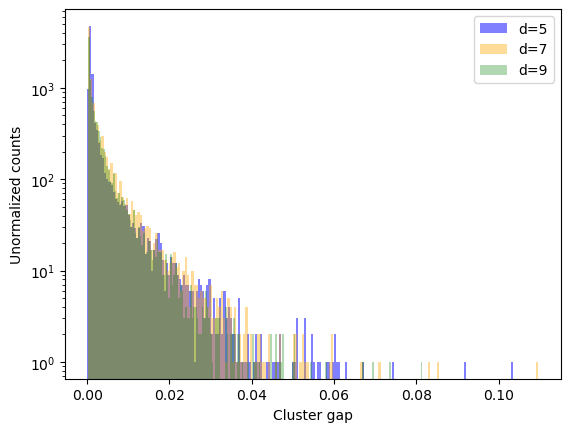

In [11]:
# cluster gap histogram tests 
import matplotlib.pyplot as plt


# to get distinct humps in cluster gap, probably need to do some log scaling ... not sure what that will look like

d_list = [5,7,9]
colors = ['blue','orange','green']
alphas = [0.5,0.4,0.3]
mem_type = "z"
p = 0.005
shots=10**4

circuits = get_rsc_circuits(p, d_list, mem_type)

for i,d in enumerate(d_list):
    circuit = circuits[i]
    sampler = circuit.compile_detector_sampler()
    det_events, obs_flips = sampler.sample(shots=shots, separate_observables=True)
    log_errors, cluster_gap, cond_pL = get_cluster_gap(circuit, det_events, obs_flips)
    plt.hist(cluster_gap, bins=200, color=colors[i], label=f"d={d}", alpha=alphas[i])
    plt.xlabel('Cluster gap')
    plt.ylabel('Unormalized counts')
    plt.legend()
plt.yscale('log')

In [ ]:
# comp gap and cluster gap comparison strong and weak decoders fig 6 of dec switching paper - maybe not ... tesseract is not a cluster growing decoder ... 
# tesseract does have a cost_from_errors(predicted_errors) function apparently

In [ ]:
# is there a fast way to get comp gap / cluster gap distribution and then sample from it later given the syndrome?? How do they do this stuff quickly bc i feel like it takes a hot min to calculate gaps for switching
# try a lookup table




# Sliding Window memory implementation time

In [63]:
# decode with sliding window using their weak decoder - use their example https://github.com/seokhyung-lee/ldpc-post-selection/blob/main/examples/basic_usage.ipynb

# check if soft outputs has committed faults on regular decode, or just sliding window decode
# if I do sliding window with bplsd and Yingjia's, can I just index and run twice? or is that not feasible

# Example circuit
from ldpc_post_selection.stim_tools import remove_detectors_from_circuit

circuit = rsc_circuits[0]
# circuit.get_detector_coordinates()

bplsd = SoftOutputsBpLsdDecoder(
    circuit=circuit,
    max_iter=30,
    bp_method="minimum_sum",
    lsd_method="LSD_0",
    lsd_order=0,
    ms_scaling_factor=1.0,
    detector_time_coords=0,
)
sampler = circuit.compile_detector_sampler(seed=42)
det, obs = sampler.sample(shots=1, separate_observables=True)

window_size = 3
commit_size = 1

correction, soft_outputs = bplsd.decode_sliding_window(
    det[0], window_size=window_size, commit_size=commit_size
)

obs_correction = correction @ bplsd.obs_matrix.T % 2
success = np.all(obs[0] == obs_correction)

from pprint import pprint

print("Correction:", correction)
print("Decoding success:", success)
print()
print("Soft outputs:")
pprint(soft_outputs)

Correction: [False False False ... False False False]
Decoding success: True

Soft outputs:
{'all_clusters': [array([0, 0, 0, ..., 0, 0, 0], shape=(3220,)),
                  array([0, 0, 0, ..., 0, 0, 0], shape=(3220,)),
                  array([0, 0, 0, ..., 0, 0, 0], shape=(3220,)),
                  array([0, 0, 0, ..., 0, 0, 0], shape=(3220,)),
                  array([0, 0, 0, ..., 0, 0, 0], shape=(3220,)),
                  array([0, 0, 0, ..., 0, 0, 0], shape=(3220,)),
                  array([0, 0, 0, ..., 0, 0, 0], shape=(3220,)),
                  array([0, 0, 0, ..., 0, 0, 0], shape=(3220,)),
                  array([0, 0, 0, ..., 0, 0, 0], shape=(3220,)),
                  array([0, 0, 0, ..., 0, 0, 0], shape=(3220,)),
                  array([0, 0, 0, ..., 0, 0, 0], shape=(3220,))],
 'committed_clusters': [array([False, False, False, ..., False, False, False], shape=(3220,)),
                        array([False, False, False, ..., False, False, False], shape=(3220,)),
  

In [64]:
# Computing commited cluster norm fractions

# not sure how commit_size, lookback_window_size, and window size relate to L,F,W and if they do?
# commit size = F, lookback size = L, window size = W, not sure how to pick these params tho

from ldpc_post_selection.sliding_window_tools import CommittedClusterNormCalculator

# A calculator instance with pre-computed information
# Can be efficiently reused for multiple samples or metric parameters
committed_cluster_norm_calculator = CommittedClusterNormCalculator(
    committed_faults=soft_outputs["committed_faults"],
    priors=bplsd.priors,
    H=bplsd.H,
)
total_rounds = d + 2
# Computing the committed cluster norm fraction for a sample
# for a given norm order, value type, and lookback window size
norm_order = 2
value_type = "llr"  # 'llr' or 'size'
lookback_window_size = 3
norm_fracs = committed_cluster_norm_calculator.compute(
    committed_clusters=soft_outputs["committed_clusters"],
    norm_order=norm_order,
    value_type=value_type,
    lookback_window_size=lookback_window_size,
)

print(
    f"Committed cluster {value_type.upper()} {norm_order}-norm fractions for each evaluation region:"
)
for i, norm_frac in enumerate(norm_fracs):
    i_window = i + lookback_window_size - 1
    i_round = i_window * commit_size + window_size - 1
    round_text = (
        f"round {i_round}" if i_round < total_rounds else "data qubit measurement"
    )
    print(f"  After window {i_window} ({round_text}): {norm_frac}")
print("  (Window and round indices start from 0.)")

Committed cluster LLR 2-norm fractions for each evaluation region:
  After window 2 (round 4): 0.004050438592548505
  After window 3 (round 5): 0.004560927681776249
  After window 4 (round 6): 0.002705864176627029
  After window 5 (round 7): 0.0014542438571160034
  After window 6 (round 8): 0.0008081900184527405
  After window 7 (round 9): 0.0008413116663818634
  After window 8 (round 10): 0.0009454060202558664
  After window 9 (data qubit measurement): 0.0018041645724962763
  After window 10 (data qubit measurement): 0.001670307764439186
  (Window and round indices start from 0.)


In [ ]:
# Sampling & decoding

from tqdm import tqdm

shots = 10000
window_size = 9
commit_size = 9
circuit = rsc_circuits[0]

bplsd = SoftOutputsBpLsdDecoder(
    circuit=circuit,
    max_iter=30,
    bp_method="minimum_sum",
    lsd_method="LSD_0",
    lsd_order=0,
    ms_scaling_factor=1.0,
    detector_time_coords=0,
)

sampler = circuit.compile_detector_sampler(seed=42)
det, obs = sampler.sample(shots=shots, separate_observables=True)

fails = []
committed_clusters = []
committed_faults = None

# running all of sliding window ... is there a way to do this without running the whole window?

for i_sample in tqdm(list(range(shots))):
    correction, soft_outputs = bplsd.decode_sliding_window(
        det[i_sample], window_size=window_size, commit_size=commit_size # run sliding window for this shot
    )
    obs_correction = correction @ bplsd.obs_matrix.T % 2
    fail = np.any(obs[i_sample] != obs_correction)
    fails.append(fail)
    committed_clusters.append(soft_outputs["committed_clusters"])
    if committed_faults is None:
        committed_faults = soft_outputs["committed_faults"]

fails = np.array(fails)

100%|██████████| 10000/10000 [01:11<00:00, 140.30it/s]


In [53]:
# Calculating committed cluster norm fractions

norm_order = 2
value_type = "llr"  # 'llr' or 'size'
lookback_window_size = 3

committed_cluster_norm_calculator = CommittedClusterNormCalculator(
    committed_faults=committed_faults,
    priors=bplsd.priors,
    H=bplsd.H,
)



norm_fracs = []
for i_sample in tqdm(list(range(shots))):
    norm_fracs_sample = committed_cluster_norm_calculator.compute(
        committed_clusters=committed_clusters[i_sample],
        norm_order=norm_order,
        value_type=value_type,
        lookback_window_size=lookback_window_size,
    )
    norm_fracs.append(norm_fracs_sample)
norm_fracs = np.vstack(norm_fracs)

window_indices = np.arange(norm_fracs.shape[1]) + lookback_window_size - 1
round_indices = window_indices * commit_size + window_size - 1
round_indices = np.minimum(round_indices, total_rounds - 1)

print(norm_fracs.shape)

# Round indice for each evaluation region (row of norm_fracs)
# The final data qubit measurement is treated to be included in the last round.
round_indices

100%|██████████| 10000/10000 [00:05<00:00, 1854.18it/s]

(10000, 9)


array([ 4,  5,  6,  7,  8,  9, 10, 10, 10])

In [ ]:
# how do I get LLR from a window of sliding window? / soft output? can just decode with bplsd ... also the package has a sliding window too

# also wanna do cluster gap with tesseract / other strong decoder? is that possible? want fig 6 of decoder switching paper

# yingjia says I need to make a class with a decode function and pass it into quits sliding window

# LER/ thr with varying cutoffs

In [ ]:
# sliding window with strong decoder if above / below cutoff


# not sure how to set W, F, L

# use QUITS sliding window with my decoder to get LER

# 

In [ ]:
# switching rates plots

## weak decoder thresholds with sliding window

In [11]:
import numpy as np
import relay_bp
from scipy.sparse import csr_matrix
from quits.decoder import sliding_window_circuit_mem 
from quits.simulation import get_stim_mem_result

class RelayBpWrapper:
    def __init__(self, check_matrix, **params):
        """
        Initializes Relay-BP using positional arguments.
        """
        if not isinstance(check_matrix, csr_matrix):
            check_matrix = csr_matrix(check_matrix)
            
        priors = params.get('priors')
        gamma0 = params.get('gamma0', 0.3)
        gamma_dist_interval = params.get('gamma_dist_interval', 0.4)
        num_sets = params.get('num_sets', 10)
        relay_max_iter = params.get('relay_max_iter', params.get('max_iter', 30))

        # Rust constructor requires exact positional order
        self.decoder = relay_bp.RelayDecoderF32(
            check_matrix, priors, gamma0, gamma_dist_interval, num_sets, relay_max_iter
        )

    def decode(self, syndrome):
        """
        Ensures the syndrome is in a format compatible with the Rust backend.
        """
        # 1. Cast to uint8 (binary) which is what 'PyArray<T, D>' expects for syndromes
        # 2. Ensure memory is contiguous (no slices/views)
        binary_syndrome = np.ascontiguousarray(syndrome, dtype=np.uint8)
        
        # Now pass the cleaned array to the Rust method
        return self.decoder.decode(binary_syndrome)
    
# Configure your Relay-BP settings
dict_RELAY = {
    'num_sets': 10,           # Number of relay ensembles to run
    'gamma0': 0.3,            # Ordered memory parameter
    'max_iter': 30,           # Max iterations per set
    'gamma_dist_interval': 0.4 # Range for random memory weights
}


num_shots = 10
circuit = rsc_circuits[0]
code_params = rsc_codes[0]
W, F = 5,1


logical_pred = sliding_window_circuit_mem(
    det_events,
    circuit,
    code_params[0],      # hz
    code_params[1],      # lz
    W,
    F,
    RelayBpWrapper,      # Use our new wrapper
    RelayBpWrapper,
    dict_RELAY,
    dict_RELAY,
    'priors',            # Tells QUITS to put priors in dict_RELAY['priors']
    'priors',
    'decode',
    'decode',
)

## strong decoder thresholds with sliding window

In [92]:
# strong decoding thresholds - start by just making sure code works
from quits.decoder import sliding_window_circuit_mem 
from quits.simulation import get_stim_mem_result
from ldpc_post_selection.decoder import SoftOutputsBpLsdDecoder
from scipy.sparse import csc_matrix

num_shots = 10
p_list = [5e-3, 1e-2, 3e-2]
d_list = [6]
mem_type='z'

results=[]
for p in p_list:
    rsc_circuits, rsc_codes = get_rsc_circuits(p, d_list,mem_type)
    circuit, code_params = rsc_circuits[0], rsc_codes[0]
    det_events, obs_flips = get_stim_mem_result(circuit, num_shots)
    W = 5
    F = 1

    # try gemini suggestion and get H and L from SoftouputsBPLSD package - if using RSC have to do this methinks
    bplsd = SoftOutputsBpLsdDecoder(
        circuit=circuit,
        max_iter=30,
        bp_method="minimum_sum",
        lsd_method="LSD_0",
        lsd_order=0,
        ms_scaling_factor=1.0,
        detector_time_coords=0,
    )


    dict_BPLSD = {
        'max_iter': 30,
        'bp_method': 'minimum_sum',
        'lsd_method': "LSD_0",
        'lsd_order': 0,
        'ms_scaling_factor':1.0,
        'detector_time_coords':0
    }
    class HardBpLsdDecoder(SoftOutputsBpLsdDecoder):
        """
        A wrapper for SoftOutputsBpLsdDecoder that only returns the 
        hard correction for compatibility with QUITS.
        """
        def decode(self, syndrome):
            # The original method returns (correction, soft_outputs)
            result = super().decode(syndrome)
            # Return only the correction array
            return result[0]

    # Now use this wrapper in your sliding_window_circuit_mem call
    logical_pred = sliding_window_circuit_mem(
        det_events,
        circuit,
        code_params[0],
        code_params[1],
        W,
        F,
        HardBpLsdDecoder, # Use the wrapper here
        HardBpLsdDecoder, # And here
        dict_BPLSD,
        dict_BPLSD,
        'p',
        'p',
        'decode',
        'decode',
    )

    pL = np.mean((obs_flips - logical_pred).any(axis=1))
    lfr = 1 - (1 - pL) ** (1 / d_list[0])
    results.append((p, float(lfr)))
    
print(results)


[(0.005, 0.0), (0.01, 0.03650751600100388), (0.03, 0.14162578106744295)]


## threshold with switching

In [ ]:
import numpy as np
import relay_bp
from scipy.sparse import csr_matrix
from ldpc_post_selection.decoder import SoftOutputsBpLsdDecoder

class DecoderSwitchingWrapper_BPLSD_RELAYBP:
    def __init__(self, check_matrix, **params):
        # ... (Previous initialization code) ...
        priors = params.get('priors')
        
        # 1. BPLSD Setup
        bplsd_keys = ['max_iter', 'bp_method', 'lsd_method', 'lsd_order', 
                      'ms_scaling_factor', 'detector_time_coords']
        bplsd_params = {k: params[k] for k in bplsd_keys if k in params}
        self.bplsd = SoftOutputsBpLsdDecoder(H=check_matrix, p=priors, **bplsd_params)
        
        # 2. Relay-BP Setup
        gamma0 = params.get('gamma0', 0.3)
        gamma_dist_interval = params.get('gamma_dist_interval', 0.4)
        num_sets = params.get('num_sets', 10)
        relay_max_iter = params.get('relay_max_iter', params.get('max_iter', 30))
        
        if not isinstance(check_matrix, csr_matrix):
            check_matrix = csr_matrix(check_matrix)
            
        self.relay_bp = relay_bp.RelayDecoderF32(
            check_matrix, priors, gamma0, gamma_dist_interval, num_sets, relay_max_iter
        )
        
        # 3. Switching & Counting Logic
        self.cutoff = params.get('switching_cutoff', 10.0)
        self.metric_key = params.get('metric_key', 'pred_llr')
        self.verbose = params.get('verbose_switch', False)
        
        # We store a reference to the mutable list passed in dict_SWITCH
        self.count_container = params.get('switch_count_container')

    def decode(self, syndrome):
        corr_bplsd, _, _, soft_info = self.bplsd.decode(syndrome)
        cluster_gap = soft_info.get(self.metric_key, 0.0)
        
        if cluster_gap > self.cutoff:
            # Increment the shared counter if it exists
            if self.count_container is not None:
                self.count_container[0] += 1
                
            if self.verbose:
                print(f"[Switch] cluster_gap {cluster_gap:.2f} < {self.cutoff}. Falling back.")
            
            binary_syndrome = np.ascontiguousarray(syndrome, dtype=np.uint8)
            return self.relay_bp.decode(binary_syndrome)
        
        return corr_bplsd

num_shots = 10
p_list = [5e-3, 1e-2, 3e-2]
d_list = [6]
mem_type='z'
W, F = 5,3

results = []
for p in p_list:
    rsc_circuits, rsc_codes = get_rsc_circuits(p, d_list, mem_type)
    circuit, code_params = rsc_circuits[0], rsc_codes[0]
    det_events, obs_flips = get_stim_mem_result(circuit, num_shots)

    # We use a list [0] because lists are mutable and 
    # changes will persist across all decoder instances.
    counter = [0]

    dict_SWITCH = {
        'bp_method': 'minimum_sum',
        'lsd_method': "LSD_0",
        'lsd_order': 0,
        'ms_scaling_factor': 1.0,
        'detector_time_coords': 2,
        'num_sets': 15,
        'gamma0': 0.3,
        'gamma_dist_interval': 0.4,
        'max_iter': 30,
        'switching_cutoff': 15.0,
        'metric_key': 'pred_llr',
        'verbose_switch': False, # Set to False for cleaner output
        'switch_count_container': counter # Pass the shared counter here
    }

    logical_pred = sliding_window_circuit_mem(
        det_events, circuit, code_params[0], code_params[1],
        W, F, DecoderSwitchingWrapper_BPLSD_RELAYBP, DecoderSwitchingWrapper_BPLSD_RELAYBP,
        dict_SWITCH, dict_SWITCH, 'priors', 'priors', 'decode', 'decode'
    )    
    
    pL = np.mean((obs_flips - logical_pred).any(axis=1))
    lfr = 1 - (1 - pL) ** (1 / d_list[0])
    
    # Report the count
    print(f"p={p}: Switched to Relay-BP {counter[0]} times across all shots and windows.")
    results.append((p, float(pL), counter[0]))
    
print("\nFinal Results (p, LER, Switch Count):")
print(results)

p=0.005: Switched to Relay-BP 15 times across all shots and windows.
p=0.01: Switched to Relay-BP 20 times across all shots and windows.
p=0.03: Switched to Relay-BP 20 times across all shots and windows.

Final Results (p, LER, Switch Count):
[(0.005, 0.3, 15), (0.01, 0.5, 20), (0.03, 0.7, 20)]


In [5]:
class RelayBpWrapper:
    def __init__(self, check_matrix, **params):
        if not isinstance(check_matrix, csr_matrix):
            check_matrix = csr_matrix(check_matrix)
        priors = params.get('priors')
        self.decoder = relay_bp.RelayDecoderF32(
            check_matrix, priors, 
            params.get('gamma0', 0.3), 
            params.get('gamma_dist_interval', 0.4), 
            params.get('num_sets', 10), 
            params.get('relay_max_iter', 30)
        )
    def decode(self, syndrome):
        binary_syndrome = np.ascontiguousarray(syndrome, dtype=np.uint8)
        return self.decoder.decode(binary_syndrome)

In [ ]:
from realtime_decoding.decoding import DecoderSwitchingWrapper
from quits.decoder import sliding_window_circuit_mem 
from quits.simulation import get_stim_mem_result
from ldpc_post_selection.decoder import SoftOutputsBpLsdDecoder
from scipy.sparse import csr_matrix
import relay_bp
import numpy as np


results = []
p_list = [0.001, 0.005, 0.006]
num_shots = 10
d_list = [6]
mem_type='z'
W, F = 5,3
for p in p_list:
    bb_circuits, bb_codes = get_BB_circuits(bb_code_param_dict, mem_type, p)
    circuit, code = bb_circuits[0], bb_codes[0]
    code_params = code.hz, code.lz
    # rsc_circuits, rsc_codes = get_rsc_circuits(p,d_list, mem_type)
    # circuit, code_params = rsc_circuits[0],rsc_codes[0]
    det_events, obs_flips = get_stim_mem_result(circuit, num_shots)
    # Initialize a new counter for this probability
    switch_counter = [0]

    dict_SWITCH = {
        # --- BPLSD Params ---
        'bp_method': 'minimum_sum',
        'lsd_method': "LSD_0",
        'detector_time_coords': 0, # index 2 for Stim RSC
        'max_iter': 20,
        
        # --- Switching Params ---
        'switching_cutoff': 0.001, 
        'metric_key': 'cluster_llrs', # or cluster_sizes
        'switch_count_container': switch_counter,
        
        # --- Relay-BP Fallback Config ---
        'strong_decoder_class': RelayBpWrapper,
        'strong_decoder_params': {
            'num_sets': 20,           # Use more sets for the fallback
            'gamma0': 0.3,
            'gamma_dist_interval': 0.4,
            'relay_max_iter': 30      # More iterations for the harder syndromes
        }
    }

    logical_pred = sliding_window_circuit_mem(
        det_events, circuit, code_params[0], code_params[1],
        W, F, 
        DecoderSwitchingWrapper, 
        DecoderSwitchingWrapper,
        dict_SWITCH, dict_SWITCH, 
        'priors', 'priors', 'decode', 'decode'
    )    
    
    pL = np.mean((obs_flips - logical_pred).any(axis=1))
    print(f"p={p}: Switches to Relay-BP: {switch_counter[0]}")
    results.append((p, float(pL), switch_counter[0]))

print("\nFinal Results:", results)

0.0009226198347852869
0.0015102257373097294
0.0010012165196438625
0.0011246431233675244
0.0008795940013266641
0.0010010707926807329
0.0005511828597028364
0.0005031573330310423
0.0010936406441129339
0.0015603221787497863
0.00043167201954547957
0.0014545280899667407
0.000832462278824595
0.001186971188626775
0.0011376085111839387
0.0008605101178694499
0.0027004352451036745
0.0010010707926807329


In [ ]:
import numpy as np
import pandas as pd
import os
import stim
from joblib import Parallel, delayed

# --- Worker Function ---
def run_single_trial(p, d, cutoff, code_type, num_shots, W, F, basis, csv_filename):
    # 1. Circuit/Code Setup
    if code_type == "RSC":
        rsc_circuits, rsc_codes = get_rsc_circuits(p, [d], basis)
        circuit, code_params = rsc_circuits[0], rsc_codes[0]
        det_time_index = 2 
    else:
        bb_circuit, bb_code = get_BB_circuit(d, basis, p)
        circuit = bb_circuit
        code_params = (bb_code.hx, bb_code.lx) if basis == 'x' else (bb_code.hz, bb_code.lz)
        det_time_index = 0 

    sampler = circuit.compile_detector_sampler()
    det_events, obs_flips = sampler.sample(shots=num_shots, separate_observables=True)

    trial_switch_counter = [0]
    
    # Configure Primary and Strong Decoders
    dict_SWITCH = {
        'bp_method': 'minimum_sum',
        'lsd_method': "LSD_0", # Keep this simple to prevent hangs
        'lsd_order': 0,        # Don't try high-order LSD in the primary step
        'detector_time_coords': det_time_index,
        'max_iter': 10,
        'switching_cutoff': cutoff,
        'switch_count_container': trial_switch_counter,
        'strong_decoder_class': RelayBpWrapper,
        'strong_decoder_params': {'num_sets': 20, 'relay_max_iter': 30}
    }

    # 2. Decoding (Using the Switching Wrapper we built)
    logical_pred = sliding_window_circuit_mem(
        det_events, circuit, code_params[0], code_params[1],
        W, F, DecoderSwitchingWrapper, DecoderSwitchingWrapper,
        dict_SWITCH, dict_SWITCH, 'priors', 'priors', 'decode', 'decode'
    )    

    pL = np.mean((obs_flips - logical_pred).any(axis=1))

    # 3. Flatten and Log
    row = {
        'LER': float(pL), 'cutoff': cutoff, 'p': p, 'd': d, 'basis': basis, 
        'num_shots': num_shots, 'code_type': code_type, 'num_switches': trial_switch_counter[0]
    }
    # Save parameters for reproducibility
    for k, v in dict_SWITCH.items():
        if k not in ['strong_decoder_class', 'strong_decoder_params', 'switch_count_container']:
            row[f"bplsd_{k}"] = v
    for k, v in dict_SWITCH['strong_decoder_params'].items():
        row[f"strong_{k}"] = v

    # --- CRITICAL: Immediate Save to CSV ---
    df_row = pd.DataFrame([row])
    # Use a file lock or just trust append mode for atomic-ish writes
    header = not os.path.exists(csv_filename)
    df_row.to_csv(csv_filename, mode='a', index=False, header=header)
    
    return row

# --- Orchestrator ---
if __name__ == "__main__":
    p_list = [0.001, 0.003, 0.005, 0.008, 0.01]
    d_list = [6,10,12]
    W,F = 5,3
    cutoff_list = [0.005, 0.007, 0.01, 0.05, 0.1]
    code_types = ["RSC", "BB"]
    num_shots = 10_000
    basis='z'
    csv_filename = "bplsd_relaybp.csv"
    
    tasks = [(p, d, c, ct) for p in p_list for d in d_list for c in cutoff_list for ct in code_types]

    print(f"Starting overnight run: {len(tasks)} trials.")
    
    # We don't necessarily need to capture 'results' since we save inside the worker
    Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_trial)(p, d, c, ct, num_shots, W, F, basis, csv_filename) 
        for p, d, c, ct in tasks
    )

    df = pd.DataFrame(results)
    header = not os.path.exists(csv_filename)
    df.to_csv(csv_filename, mode='a', index=False, header=header)
    print(f"Data saved to {csv_filename}")

In [5]:
import numpy as np
import pandas as pd
import os
from filelock import FileLock
import relay_bp
from joblib import Parallel, delayed
from scipy.sparse import csr_matrix
from ldpc_post_selection.decoder import SoftOutputsBpLsdDecoder
from quits.decoder import sliding_window_circuit_mem
from realtime_decoding.decoding import DecoderSwitchingWrapper



# --- 2. Decoder Wrappers ---

class RelayBpWrapper:
    def __init__(self, check_matrix, **params):
        if not isinstance(check_matrix, csr_matrix):
            check_matrix = csr_matrix(check_matrix)
        priors = params.get('priors')
        self.decoder = relay_bp.RelayDecoderF32(
            check_matrix, priors, 
            params.get('gamma0', 0.3), 
            params.get('gamma_dist_interval', 0.4), 
            params.get('num_sets', 10), 
            params.get('relay_max_iter', 10)
        )
    def decode(self, syndrome):
        binary_syndrome = np.ascontiguousarray(syndrome, dtype=np.uint8)
        return self.decoder.decode(binary_syndrome)


# --- 3. The Unified Worker Function ---

def run_single_trial(p, d, cutoff, code_type, num_shots, W, F, basis):
    # 1. Circuit Generation Logic
    if code_type == "RSC":
        rsc_circuits, rsc_codes = get_rsc_circuits(p,[d],basis)
        circuit, code_params = rsc_circuits[0], rsc_codes[0]
        det_time_index = 2 # (x, y, t)
    else:
        bb_circuit, bb_code = get_BB_circuit(d, basis, p)
        circuit=bb_circuit
        if basis == 'x':
            code_params = bb_code.hx, bb_code.lx
        else:
            code_params = bb_code.hz, bb_code.lz
        det_time_index = 0 # (t,)

    sampler = circuit.compile_detector_sampler()
    det_events, obs_flips = sampler.sample(shots=num_shots, separate_observables=True)

    trial_switch_counter = [0]
    dict_SWITCH = {
        # --- BPLSD Params ---
        'bp_method': 'minimum_sum',
        'lsd_method': "LSD_0",
        'lsd_order': 0,
        'detector_time_coords': det_time_index,
        'max_iter': 10,
        
        # --- Switching Params ---
        'switching_cutoff': cutoff, 
        'metric_key': 'cluster_llrs', # or cluster_sizes
        'switch_count_container': trial_switch_counter,
        
        # --- Relay-BP Fallback Config ---
        'strong_decoder_class': RelayBpWrapper,
        'strong_decoder_params': {
            'num_sets': 20,           # Use more sets for the fallback
            'gamma0': 0.3,
            'gamma_dist_interval': 0.4,
            'relay_max_iter': 30      # More iterations for the harder syndromes
        }
    }

    # 2. Decoding
    # Note: Using quits sliding window function
    logical_pred = sliding_window_circuit_mem(
        det_events, circuit, code_params[0], code_params[1],
        W, F, DecoderSwitchingWrapper, DecoderSwitchingWrapper,
        dict_SWITCH, dict_SWITCH, 'priors', 'priors', 'decode', 'decode'
    )    

    pL = np.mean((obs_flips - logical_pred).any(axis=1))

    # 3. Log Preparation
    row = {
        'LER': float(pL), 'cutoff': cutoff, 'p': p, 'd': d, 'basis':basis, 'cluster_metric':dict_SWITCH['metric_key'],
        'num_shots': num_shots, 'code_type': code_type, 'num_switches': trial_switch_counter[0]
    }
    for k, v in dict_SWITCH.items():
        if k not in ['strong_decoder_class', 'strong_decoder_params', 'switch_count_container', 'metric_key', 'priors', 'detector_time_coords']:
            row[f"bplsd_{k}"] = v
    for k, v in dict_SWITCH['strong_decoder_params'].items():
        row[f"strong_{k}"] = v
    
    # 2. Use a Lock to write to the CSV safely
    # This creates a '.lock' file. Processes will wait their turn to write.
    lock_path = csv_filename + ".lock"
    lock = FileLock(lock_path)
    
    with lock:
        df_row = pd.DataFrame([row])
        header_needed = not os.path.exists(csv_filename)
        # We open, write, and close the file immediately
        df_row.to_csv(csv_filename, mode='a', index=False, header=header_needed)
    
    return row

# --- 4. Main Parallel Execution ---

if __name__ == "__main__":
    p_list = [0.001, 0.003, 0.005, 0.008, 0.01]
    d_list = [6,10,12]
    W,F = 5,3
    cutoff_list = [0.005, 0.007, 0.01, 0.05, 0.1]
    code_types = ["RSC", "BB"]
    num_shots = 100_000
    basis='x'
    csv_filename = "bplsd_relaybp.csv"

    # Create all combinations of tasks
    tasks = [(p, d, c, ct) for p in p_list for d in d_list for c in cutoff_list for ct in code_types]

    print(f"Starting parallel simulation for {len(tasks)} combinations...")
    
    results = Parallel(n_jobs=-1, verbose=0)(
        delayed(run_single_trial)(p, d, cutoff, code_type, num_shots, W, F,basis) for p, d, cutoff, code_type in tasks
    )


Starting parallel simulation for 150 combinations...


KeyboardInterrupt: 

In [ ]:
# Weak decoding LER


In [17]:
# strong decoding LER
from joblib import Parallel, delayed
from quits.decoder import sliding_window_circuit_mem
import relay_bp
from scipy.sparse import csr_matrix
from filelock import FileLock
from tqdm import tqdm
import numpy as np
import pandas as pd
import os

class RelayBpWrapper:
    def __init__(self, check_matrix, **params):
        if not isinstance(check_matrix, csr_matrix):
            check_matrix = csr_matrix(check_matrix)
        priors = params.get('priors')
        self.decoder = relay_bp.RelayDecoderF32(
            check_matrix, priors, 
            params.get('gamma0', 0.3), 
            params.get('gamma_dist_interval', 0.4), 
            params.get('num_sets', 10), 
            params.get('relay_max_iter', 10)
        )
    def decode(self, syndrome):
        binary_syndrome = np.ascontiguousarray(syndrome, dtype=np.uint8)
        return self.decoder.decode(binary_syndrome)


# --- 3. The Unified Worker Function ---

def run_single_trial(p, d, code_type, num_shots, W, F, basis):
    # 1. Circuit Generation Logic
    if code_type == "RSC":
        rsc_circuits, rsc_codes = get_rsc_circuits(p,[d],basis)
        circuit, code_params = rsc_circuits[0], rsc_codes[0]
        det_time_index = 2 # (x, y, t)
    else:
        bb_circuit, bb_code = get_BB_circuit(d, basis, p)
        circuit=bb_circuit
        if basis == 'x':
            code_params = bb_code.hx, bb_code.lx
        else:
            code_params = bb_code.hz, bb_code.lz
        det_time_index = 0 # (t,)

    sampler = circuit.compile_detector_sampler()
    det_events, obs_flips = sampler.sample(shots=num_shots, separate_observables=True)


    dict_RELAY = {
            'num_sets': 20,           # Use more sets for the fallback
            'gamma0': 0.3,
            'gamma_dist_interval': 0.4,
            'relay_max_iter': 30      # More iterations for the harder syndromes
        }

    # 2. Decoding
    # Note: Using quits sliding window function
    logical_pred = sliding_window_circuit_mem(
        det_events, circuit, code_params[0], code_params[1],
        W, F, RelayBpWrapper, RelayBpWrapper,
        dict_RELAY, dict_RELAY, 'priors', 'priors', 'decode', 'decode'
    )    

    pL = np.mean((obs_flips - logical_pred).any(axis=1))

    # 3. Log Preparation
    row = {
        'LER': float(pL), 'cutoff': None, 'p': p, 'd': d, 'basis':basis, 'cluster_metric':None,
        'num_shots': num_shots, 'code_type': code_type, 'num_switches': None
    }

    for k, v in dict_RELAY.items():
        row[f"strong_{k}"] = v
    
    # 2. Use a Lock to write to the CSV safely
    # This creates a '.lock' file. Processes will wait their turn to write.
    lock_path = csv_filename + ".lock"
    lock = FileLock(lock_path)
    
    with lock:
        df_row = pd.DataFrame([row])
        header_needed = not os.path.exists(csv_filename)
        # We open, write, and close the file immediately
        df_row.to_csv(csv_filename, mode='a', index=False, header=header_needed)
    
    return row

# --- 4. Main Parallel Execution ---

if __name__ == "__main__":
    p_list = [0.001]
    d_list = [6]
    W,F = 5,3
    # cutoff_list = [0.005, 0.007, 0.01, 0.05, 0.1]
    code_types = ["RSC", "BB"]
    num_shots_dict = {0.001: 1000, 0.003: 1000, 0.005: 1000, 0.008: 1000, 0.01:1000}
    basis='x'
    csv_filename = "relaybp.csv"

    # Create all combinations of tasks
    tasks = [(p, d, ct) for p in p_list for d in d_list for ct in code_types]

    print(f"Starting parallel simulation for {len(tasks)} combinations...")
    
    results = Parallel(n_jobs=-1, verbose=0)(
        delayed(run_single_trial)(p, d, code_type, num_shots_dict[p], W, F,basis) for p, d, code_type in tqdm(tasks)
    )

# 946 it/s

Starting parallel simulation for 2 combinations...


100%|██████████| 2/2 [00:00<00:00, 946.48it/s]


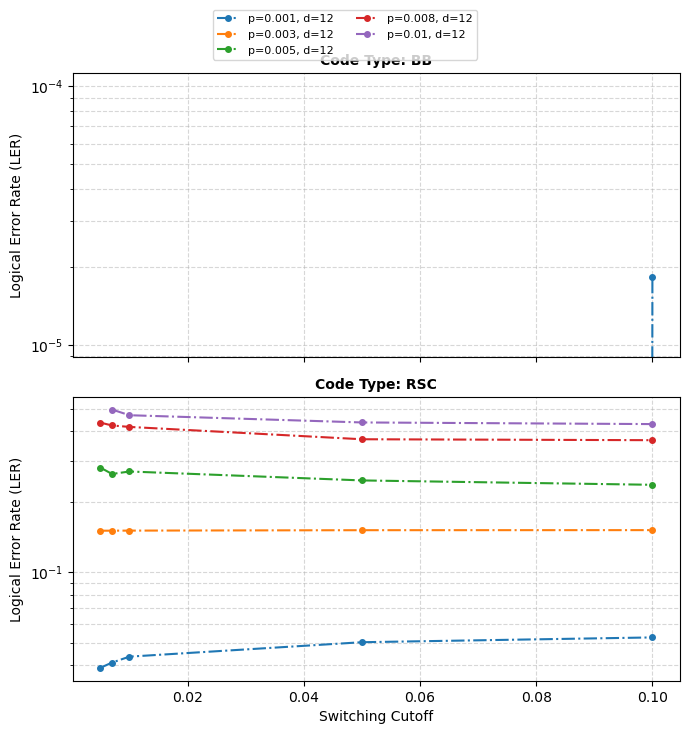

In [28]:
# plotting time ... x axis is cutoff, y-axis is LER. each code has its own linestyle, each d has its own color
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/bplsd_relaybp.csv")

# 2. Setup colors for each p and linestyles for each d
ps = sorted(df['p'].unique())
# ds = sorted(df['d'].unique())
ds = [12]

# High-contrast colors for different probabilities
colors = {0.001: '#1f77b4', 0.003: '#ff7f0e', 0.005: '#2ca02c', 
          0.008: '#d62728', 0.01: '#9467bd'}
# Linestyles for different distances
linestyles = {6: '-', 10: '--', 12: '-.'}

code_dict = {'RSC': 'Surface Code', 'BB': 'BB'}

# 3. Initialize Plot
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
plt.subplots_adjust(hspace=0.1)

code_types = ['BB', 'RSC']

for i, code in enumerate(code_types):
    ax = axes[i]
    subset_code = df[df['code_type'] == code]
    
    # Nested loops to plot each combination of p and d
    for p_val in ps:
        for d_val in ds:
            data = subset_code[(subset_code['p'] == p_val) & (subset_code['d'] == d_val)]
            if data.empty:
                continue
            
            # Sort by cutoff for proper line drawing
            data = data.sort_values('cutoff')
            
            # Calculate standard deviation as requested: 1/sqrt(num_shots)
            y_err = 1 / np.sqrt(data['num_shots'])
            
            ax.plot(data['cutoff'], data['LER'],
                        label=f"p={p_val}, d={d_val}",
                        color=colors.get(p_val, 'black'),
                        linestyle=linestyles.get(d_val, '-'),
                        marker='o', markersize=4#, capsize=3, elinewidth=1
                        )
    
    ax.set_ylabel('Logical Error Rate (LER)')
    ax.set_title(f'Code Type: {code}', fontsize=10, fontweight='bold')
    ax.set_yscale('log') # Usually LER is viewed in log scale
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

# 4. Final Formatting
axes[1].set_xlabel('Switching Cutoff')

# Single legend for the whole figure to save space
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=2, fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

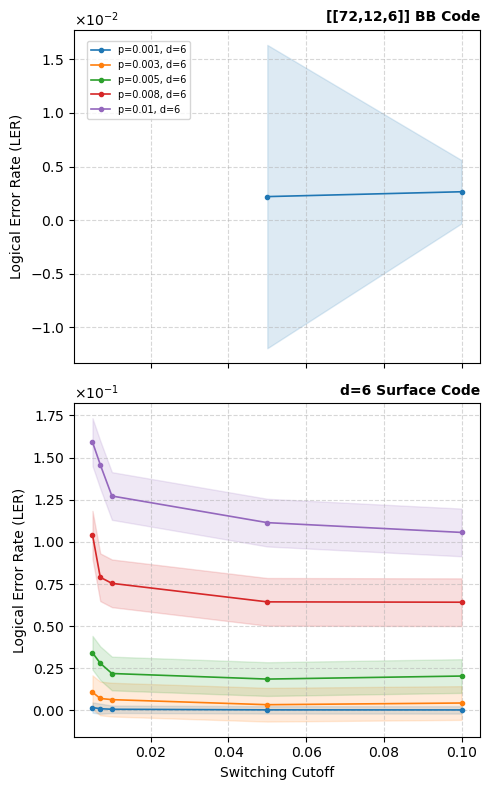

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 1. Load the data from your local file
# Replace 'data.csv' with your actual filename (e.g., 'bplsd_relaybp.csv')
df = pd.read_csv("/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/bplsd_relaybp.csv")

# 2. Define aesthetic mappings
ps = sorted(df['p'].unique())
# ps = [0.001]
# ds = sorted(df['d'].unique())
ds = [6]

# High-contrast colors for different probabilities
colors = {0.001: '#1f77b4', 0.003: '#ff7f0e', 0.005: '#2ca02c', 
          0.008: '#d62728', 0.01: '#9467bd'}
# Linestyles for different distances
linestyles = {6: '-', 10: '--', 12: '-.'}

# 3. Create subplots (thin and tall for 2-column paper)
fig, axes = plt.subplots(2, 1, figsize=(5, 8), sharex=True)
plt.subplots_adjust(hspace=0.15)

code_types = ['BB', 'RSC']
bb_dict = {6: '[[72,12,6]]', 10:'[[90,8,10]]', 12:'[[144,12,12]]'}
code_dict = {'RSC': f"d={ds[0]} Surface", 'BB': f"{bb_dict[ds[0]]} BB"}

for i, code in enumerate(code_types):
    ax = axes[i]
    subset_code = df[df['code_type'] == code]
    
    # Nested loops to plot each combination of p and d
    for p_val in ps:
        for d_val in ds:
            data = subset_code[(subset_code['p'] == p_val) & (subset_code['d'] == d_val)]
            if data.empty:
                continue
            
            # Sort by cutoff for proper line/shading rendering
            data = data.sort_values('cutoff')
            
            # Calculate standard deviation: 1/sqrt(num_shots)
            y_err = 1 / np.sqrt(data['num_shots'])
            
            line_color = colors.get(p_val, 'black')
            ls = linestyles.get(d_val, '-')
            
            # Plot the central LER line
            ax.plot(data['cutoff'], data['LER'], 
                    label=f"p={p_val}, d={d_val}",
                    color=line_color,
                    linestyle=ls,
                    marker='o', markersize=3, linewidth=1.2)
            
            # Shade the error region
            ax.fill_between(data['cutoff'], 
                            data['LER'] - y_err, 
                            data['LER'] + y_err, 
                            color=line_color, alpha=0.15)
    
    # Y-axis formatting
    ax.set_ylabel('Logical Error Rate (LER)')
    ax.set_title(f'{code_dict[code]} Code', fontsize=10, fontweight='bold', loc='right')
    
    # Apply scientific notation with power of 10 at the top
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0)) # Force scientific notation
    ax.yaxis.set_major_formatter(formatter)
    
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

all_handles, all_labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    all_handles.extend(h)
    all_labels.extend(l)

# Remove duplicates while preserving order
unique_map = dict(zip(all_labels, all_handles))
# Sort labels numerically by p then d
sorted_labels = sorted(unique_map.keys(), 
                       key=lambda x: (float(x.split(',')[0].split('=')[1]), 
                                      int(x.split(',')[1].split('=')[1])))
sorted_handles = [unique_map[label] for label in sorted_labels]

# 4. Specific adjustments
axes[1].set_xlabel('Switching Cutoff')

# Place legend in the top-left of the first (BB) plot
axes[0].legend(sorted_handles, sorted_labels, 
               loc='upper left', 
               bbox_to_anchor=(0.02, 0.98), # Adjust these numbers to nudge the position
               fontsize=7, 
               frameon=True, 
               ncol=1)

plt.tight_layout()
# Uncomment the line below to save the file for your TeX document
# plt.savefig("decoder_switching_results.pdf", bbox_inches='tight')
plt.show()

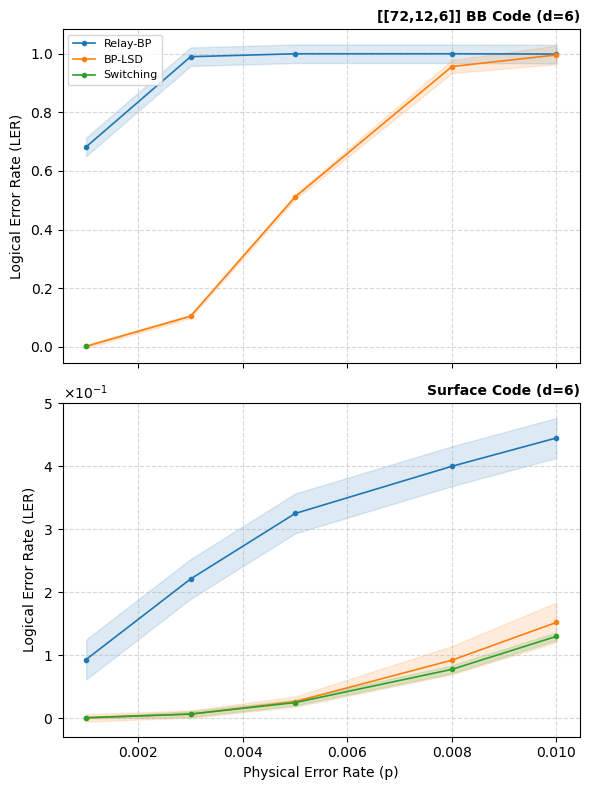

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 1. Configuration
files = {
    "/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/notebooks/relaybp.csv": {"label": "Relay-BP", "color": "#1f77b4"},
    "/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/notebooks/bplsd.csv": {"label": "BP-LSD", "color": "#ff7f0e"},
    "/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/bplsd_relaybp.csv": {"label": "Switching", "color": "#2ca02c"}
}

target_d = 6
code_types = ['BB', 'RSC']
bb_dict = {6: '[[72,12,6]]', 10:'[[90,8,10]]', 12:'[[144,12,12]]'}
code_dict = {'RSC': 'Surface', 'BB': f"{bb_dict[target_d]} BB"}

# 2. Setup Figure
fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
plt.subplots_adjust(hspace=0.15)

# 3. Aggregation and Plotting Logic
for filename, config in files.items():
    try:
        df = pd.read_csv(filename)
        
        # Filter for the shared distance
        df = df[df['d'] == target_d]
        
        for i, code in enumerate(code_types):
            ax = axes[i]
            subset = df[df['code_type'] == code]
            
            if subset.empty:
                continue
            
            # --- WEIGHTED AVERAGE LOGIC ---
            # Group by physical error rate (p) and aggregate
            # Weighted LER = sum(LER * shots) / sum(shots)
            agg_data = subset.groupby('p').apply(
                lambda x: pd.Series({
                    'LER': (x['LER'] * x['num_shots']).sum() / x['num_shots'].sum(),
                    'total_shots': x['num_shots'].sum()
                })
            ).reset_index()
            
            # Sort by p for line consistency
            agg_data = agg_data.sort_values('p')
            
            # Uncertainty shading based on total combined shots
            y_err = 1 / np.sqrt(agg_data['total_shots'])
            
            # Plot center line
            ax.plot(agg_data['p'], agg_data['LER'], 
                    label=config['label'],
                    color=config['color'],
                    marker='o', markersize=3, linewidth=1.2)
            
            # Plot shaded error region
            ax.fill_between(agg_data['p'], 
                            agg_data['LER'] - y_err, 
                            agg_data['LER'] + y_err, 
                            color=config['color'], alpha=0.15)
            
    except FileNotFoundError:
        print(f"Warning: {filename} not found.")

# 4. Formatting
for i, code in enumerate(code_types):
    ax = axes[i]
    ax.set_ylabel('Logical Error Rate (LER)')
    ax.set_title(f'{code_dict[code]} Code (d={target_d})', fontsize=10, fontweight='bold', loc='right')
    
    # Scientific notation
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0)) 
    ax.yaxis.set_major_formatter(formatter)
    
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

axes[1].set_xlabel('Physical Error Rate (p)')
axes[0].legend(loc='upper left', fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

## Switching rates

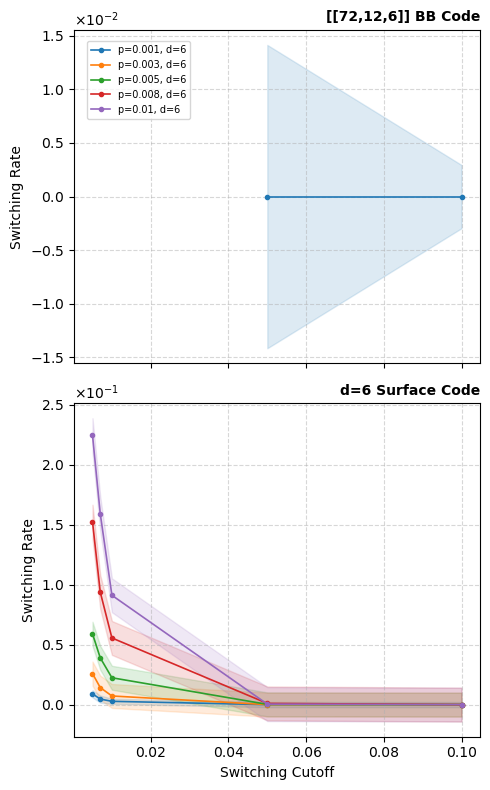

In [72]:
# switching rates plot

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 1. Load the data
df = pd.read_csv("/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/bplsd_relaybp.csv")

# 2. Define aesthetic mappings
ps = sorted(df['p'].unique())
# ps = [0.001]
# ds = sorted(df['d'].unique())
ds = [6] # Shared distance as requested

colors = {0.001: '#1f77b4', 0.003: '#ff7f0e', 0.005: '#2ca02c', 
          0.008: '#d62728', 0.01: '#9467bd'}
linestyles = {6: '-', 10: '--', 12: '-.'}

# 3. Create subplots
fig, axes = plt.subplots(2, 1, figsize=(5, 8), sharex=True)
plt.subplots_adjust(hspace=0.15)

code_types = ['BB', 'RSC']
bb_dict = {6: '[[72,12,6]]', 10:'[[90,8,10]]', 12:'[[144,12,12]]'}
code_dict = {'RSC': f"d={ds[0]} Surface", 'BB': f"{bb_dict[ds[0]]} BB"}

for i, code in enumerate(code_types):
    ax = axes[i]
    subset_code = df[df['code_type'] == code]
    
    for p_val in ps:
        for d_val in ds:
            data = subset_code[(subset_code['p'] == p_val) & (subset_code['d'] == d_val)]
            if data.empty:
                continue
            
            data = data.sort_values('cutoff')
            
            # --- CALCULATE SWITCHING RATE ---
            # Rate is the number of times we switched to the strong decoder per shot
            switching_rate = data['num_switches'] / data['num_shots']
            
            # Statistical uncertainty shading
            y_err = 1 / np.sqrt(data['num_shots'])
            
            line_color = colors.get(p_val, 'black')
            ls = linestyles.get(d_val, '-')
            
            # Plot the Switching Rate
            ax.plot(data['cutoff'], switching_rate, 
                    label=f"p={p_val}, d={d_val}",
                    color=line_color,
                    linestyle=ls,
                    marker='o', markersize=3, linewidth=1.2)
            
            # Shade the error region
            ax.fill_between(data['cutoff'], 
                            switching_rate - y_err, 
                            switching_rate + y_err, 
                            color=line_color, alpha=0.15)
    
    # Y-axis formatting
    ax.set_ylabel('Switching Rate')
    ax.set_title(f'{code_dict[code]} Code', fontsize=10, fontweight='bold', loc='right')
    
    # Apply scientific notation with power of 10 at the top
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0)) 
    ax.yaxis.set_major_formatter(formatter)
    
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

# 4. Legend Logic (Comprehensive for all p values)
all_handles, all_labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    all_handles.extend(h)
    all_labels.extend(l)

unique_map = dict(zip(all_labels, all_handles))
sorted_labels = sorted(unique_map.keys(), 
                       key=lambda x: (float(x.split(',')[0].split('=')[1]), 
                                      int(x.split(',')[1].split('=')[1])))
sorted_handles = [unique_map[label] for label in sorted_labels]

axes[0].legend(sorted_handles, sorted_labels, 
               loc='upper left', 
               bbox_to_anchor=(0.02, 0.98), 
               fontsize=7, 
               frameon=True, 
               ncol=1)

axes[1].set_xlabel('Switching Cutoff')

plt.tight_layout()
plt.show()

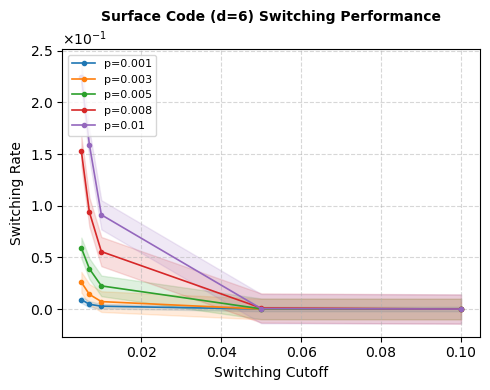

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 1. Load the data
df = pd.read_csv("/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/bplsd_relaybp.csv")

# 2. Define aesthetic mappings
ps = sorted(df['p'].unique())
ds = [6] # Filter for d=6

colors = {0.001: '#1f77b4', 0.003: '#ff7f0e', 0.005: '#2ca02c', 
          0.008: '#d62728', 0.01: '#9467bd'}

# 3. Create a single plot
fig, ax = plt.subplots(figsize=(5, 4))

# Filter specifically for the Surface Code
subset_code = df[(df['code_type'] == 'RSC') & (df['d'].isin(ds))]

for p_val in ps:
    data = subset_code[subset_code['p'] == p_val]
    if data.empty:
        continue
    
    # Sort by cutoff for proper rendering
    data = data.sort_values('cutoff')
    
    # Calculate Switching Rate
    switching_rate = data['num_switches'] / data['num_shots']
    
    # Statistical uncertainty shading
    y_err = 1 / np.sqrt(data['num_shots'])
    
    line_color = colors.get(p_val, 'black')
    
    # Plot the Switching Rate
    ax.plot(data['cutoff'], switching_rate, 
            label=f"p={p_val}",
            color=line_color,
            linestyle='-',
            marker='o', markersize=3, linewidth=1.2)
    
    # Shade the error region
    ax.fill_between(data['cutoff'], 
                    switching_rate - y_err, 
                    switching_rate + y_err, 
                    color=line_color, alpha=0.15)

# 4. Formatting
ax.set_xlabel('Switching Cutoff')
ax.set_ylabel('Switching Rate')
ax.set_title(f'Surface Code (d={ds[0]}) Switching Performance', 
             fontsize=10, fontweight='bold')

# Apply scientific notation with power of 10 at the top
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0)) 
ax.yaxis.set_major_formatter(formatter)

ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Place legend in the top-left
ax.legend(loc='upper left', fontsize=8, frameon=True)

plt.tight_layout()
# plt.savefig("surface_code_switching_rate.pdf", bbox_inches='tight')
plt.show()

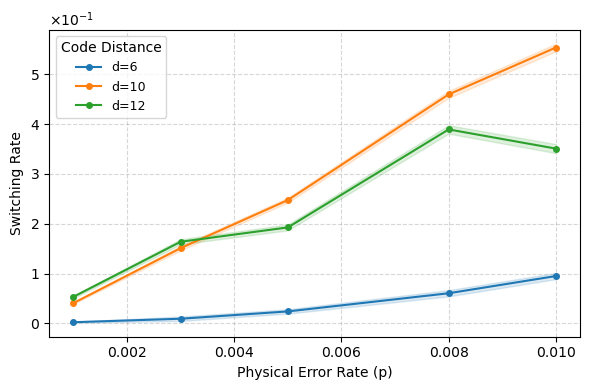

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 1. Load the data
# Replace with your actual path
path = "/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/bplsd_relaybp.csv"
df = pd.read_csv(path)

# 2. Configuration and Filtering
# Filter for Surface Code only
df_rsc = df[df['code_type'] == 'RSC']

# If your CSV contains multiple cutoff values, you should filter for one specific cutoff 
# to avoid overlapping data points on the p-axis.
# For example: df_rsc = df_rsc[df_rsc['cutoff'] == 0.01]

ds = sorted(df_rsc['d'].unique())

# Define colors for different distances d
d_colors = {6: '#1f77b4', 10: '#ff7f0e', 12: '#2ca02c'}

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(6, 4))

for d_val in ds:
    # Filter data for this specific distance
    data_d = df_rsc[df_rsc['d'] == d_val]
    
    if data_d.empty:
        continue
    
    # --- WEIGHTED AVERAGE LOGIC ---
    # We group by p to calculate the total switching rate and combined uncertainty
    # Switching Rate = sum(switches) / sum(shots)
    agg_data = data_d.groupby('p').apply(
        lambda x: pd.Series({
            'switch_rate': x['num_switches'].sum() / x['num_shots'].sum(),
            'total_shots': x['num_shots'].sum()
        })
    ).reset_index()
    
    # Sort by p for smooth line drawing
    agg_data = agg_data.sort_values('p')
    
    # Uncertainty shading: 1 / sqrt(total combined shots)
    y_err = 1 / np.sqrt(agg_data['total_shots'])
    
    color = d_colors.get(d_val, 'black')
    
    # Plot the Switching Rate vs Physical Error Rate p
    ax.plot(agg_data['p'], agg_data['switch_rate'], 
            label=f"d={d_val}",
            color=color,
            marker='o', markersize=4, linewidth=1.5)
    
    # Shade the error region
    ax.fill_between(agg_data['p'], 
                    agg_data['switch_rate'] - y_err, 
                    agg_data['switch_rate'] + y_err, 
                    color=color, alpha=0.15)

# 4. Formatting
ax.set_xlabel('Physical Error Rate (p)')
ax.set_ylabel('Switching Rate')
# ax.set_title('Surface Code Switching Rate', 
#              fontsize=10, fontweight='bold')

# Apply scientific notation with power of 10 at the top
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0)) 
ax.yaxis.set_major_formatter(formatter)

ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(title="Code Distance", loc='upper left', fontsize=9, frameon=True)

plt.tight_layout()
# plt.savefig("rsc_switching_vs_p.pdf", bbox_inches='tight')
plt.show()